### Import all packages need in the cell below

In [ ]:
using Plots, HiGHS, Ipopt, JuMP

# **1 - Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

In [9]:
# Definição da função
f(x) = sin(x)

# Domínio
x = range(-pi/4,3*pi/4, length=200)

# Avaliação da função
y = f.(x)

200-element Vector{Float64}:
 -0.7071067811865475
 -0.6958561094921814
 -0.6844320158669253
 -0.6728373474344134
 -0.6610749938290975
 -0.64914788647609
 -0.6370589978605915
 -0.6248113407870846
 -0.6124079676284803
 -0.5998519695654028
 -0.5871464758158015
 -0.5742946528550859
 -0.561299703626972
  ⋮
  0.8186486741588584
  0.8094807075755941
  0.8001110014294937
  0.7905418908477617
  0.7807757606533682
  0.770815044770702
  0.7606622256189836
  0.7503198334935968
  0.7397904459354843
  0.7290766870887704
  0.7181812270467709
  0.7071067811865476

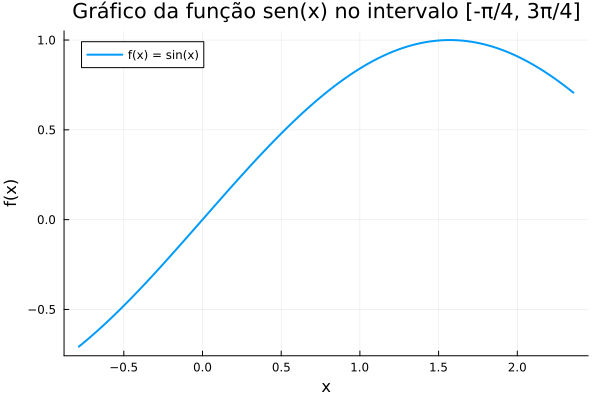

In [10]:
# Gráfico
plot(
    x,
    y,
    label = "f(x) = sin(x)",
    linewidth = 2,
    xlabel = "x",
    ylabel = "f(x)",
    title = "Gráfico da função sen(x) no intervalo [-π/4, 3π/4]"
)

# **2 - Problem Statement
Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

In [11]:
# Definição da função
f(x) = x*sin(x)

# Domínio
x = range(-10*pi,10*pi, length=200)

# Avaliação da função
y = f.(x)

200-element Vector{Float64}:
  -3.84734138744358e-14
  -9.657169349014099
 -18.173190745417028
 -24.734248129357223
 -28.735450477572478
 -29.836307237629796
 -27.988944617521845
 -23.436811576705445
 -16.684599315471775
  -8.442942541973043
   0.4460962616519082
   9.094971526271301
  16.659264954206346
   ⋮
   9.094971526271301
   0.4460962616519082
  -8.442942541973043
 -16.684599315471775
 -23.436811576705445
 -27.988944617521845
 -29.836307237629796
 -28.735450477572478
 -24.734248129357223
 -18.173190745417028
  -9.657169349014099
  -3.84734138744358e-14

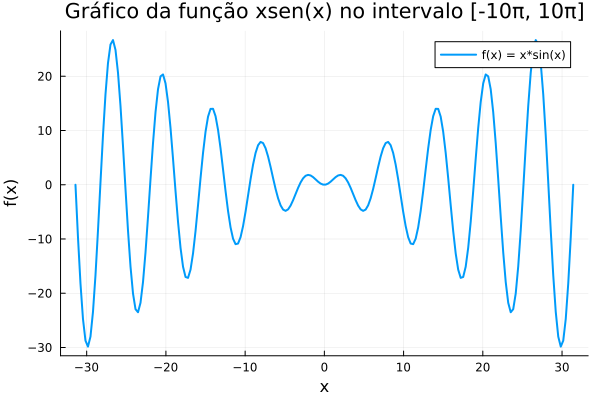

In [12]:
# Gráfico
plot(
    x,
    y,
    label = "f(x) = x*sin(x)",
    linewidth = 2,
    xlabel = "x",
    ylabel = "f(x)",
    title = "Gráfico da função xsen(x) no intervalo [-10π, 10π]"
)

# **3-Problem Statement

Solve the Cylinder Problem considering the following data:

O objetivo é determinar as dimensões ideais de um cilindro — seu raio (R) e sua altura (H) — para que o lucro seja o maior possível.

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

Formulação Matemática
A lógica do modelo baseia-se na diferença entre a receita gerada pelo volume e o custo dos materiais de construção

Receita: O volume do cilindro (πR2 H) é multiplicado por um fator de valor n por metro cúbico.
Custos de Material:
Topo: Utiliza um material com custo C1​  por m2
  aplicado sobre a área do círculo (πR2).
Fundo e Lateral: Utilizam um material com custo C2​  por m2 . O custo é aplicado sobre a área da base (πR2 ) e a área lateral (2πRH).
Restrições: R e H > (R≥0;H≥0)
.

In [1]:

using JuMP
using Ipopt


In [2]:

n  = 10.0    # valor por m³
C1 = 2.0     # custo do topo (por m²)
C2 = 0.5     # custo do fundo + lateral (por m²)


0.5

In [3]:
model = Model(Ipopt.Optimizer)

A JuMP Model
├ solver: Ipopt
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [4]:



@variable(model, R >= 0, start = 0.1)
@variable(model, H >= 0, start = 0.1)




H


"""
Função lucro do cilindro:

L(R, H) = n * π * R^2 * H
          - C1 * π * R^2
          - C2 * (π * R^2 + 2π * R * H)
"""


In [5]:

@objective(model, Max, n  * π * R^2 * H - C1 * π * R^2 - C2 * π*R^2*H*(π * R^2 + 2π * R * H)
)


(((31.41592653589793 R²) * H) - (6.283185307179586 R²)) - ((1.5707963267948966 R²) * (3.141592653589793 R² + 6.283185307179586 H*R) * H)

In [6]:
optimize!(model)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality c

In [7]:

println("Status: ", termination_status(model))

R_opt      = value(R)
H_opt      = value(H)
lucro_opt = objective_value(model)

println("Raio ótimo (R): ", R_opt)
println("Altura ótima (H): ", H_opt)
println("Lucro máximo: ", lucro_opt)

# Uso adicional (exemplo)
volume_opt = π * R_opt^2 * H_opt
println("Volume correspondente: ", volume_opt)


Status: LOCALLY_SOLVED
Raio ótimo (R): 0.8255542432640977
Altura ótima (H): 1.7214671119189964
Lucro máximo: 12.17412924094494
Volume correspondente: 3.6858684472078607


Raio Ótimo: 0,8.
Altura Ótima: 1,72.
Lucro Máximo: 12,08.

# **4-Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [1]:
using JuMP
using Ipopt


In [5]:
h  = 2.0    # altura
w = 3.0     # largura
e = 1e-6     # 

1.0e-6

In [6]:
# modelo
model = Model(Ipopt.Optimizer)

A JuMP Model
├ solver: Ipopt
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [7]:
# Criação do modelo
# Variáveis 
# Função objetivo: minizar o custo total
# Restrição

# Variáveis
@variable(model, x >= e, start =1.0)
@variable(model, y >= e, start =1.0)
@variable(model, z)

@constraint(model, z == sqrt(x^2+y^2))
@constraint(model, y -w*y/x >=h)



  

# Função objetivo: minimizar 
@objective(model, Min,z)

# Resolver
optimize!(model)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        3
Number of nonzeros in inequality constraint Jacobian.:        2
Number of nonzeros in Lagrangian Hessian.............:        6

Total number of variables............................:        3
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality c

In [8]:
println("status:", termination_status(model))

x_opt= value(x)
y_opt= value(y)
z_opt= value(z)

println("x =", x_opt)
println("y =", y_opt)
println("z =", z_opt)


status:LOCALLY_SOLVED
x =5.289428478583722
y =4.620741382379412
z =7.023482366524839


# **5-Problem Statement

Solve the Packing Problem

In [9]:
using JuMP
using Ipopt

In [17]:

# Modelo
model = Model(Ipopt.Optimizer)


A JuMP Model
├ solver: Ipopt
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [18]:
# Criação do modelo
# Variáveis 
# Função objetivo: minizar o custo total
# Restrição

# Variáveis
@variable(model, h >= 0, start =1.0)
@variable(model, w >= 0, start =1.0)
@variable(model, d >= 0, start =1.0)
@variable(model, cardboard)



# Função objetivo: maximizar o volume
@NLobjective(model, Max, w*h*d)

# Restrição: área total de papelão
@NLconstraint(model, 2*w*h+2*h*d+6*w*d <= 60)



# Resolver
optimize!(model)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:       12

Total number of variables............................:        4
                     variables with only lower bounds:        3
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0000000e+00 0.00e+00 8.69e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [20]:

println("Status: ", termination_status(model))
println("Volume máximo = ", objective_value(model))
println("h = ",value(h))
println("w = ", value(w))
println("d = ",value(d))


Status: LOCALLY_SOLVED
Volume máximo = 18.257418585563897
h = 5.477225575257443
w = 1.8257418584191745
d = 1.8257418584191747


# **6-Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

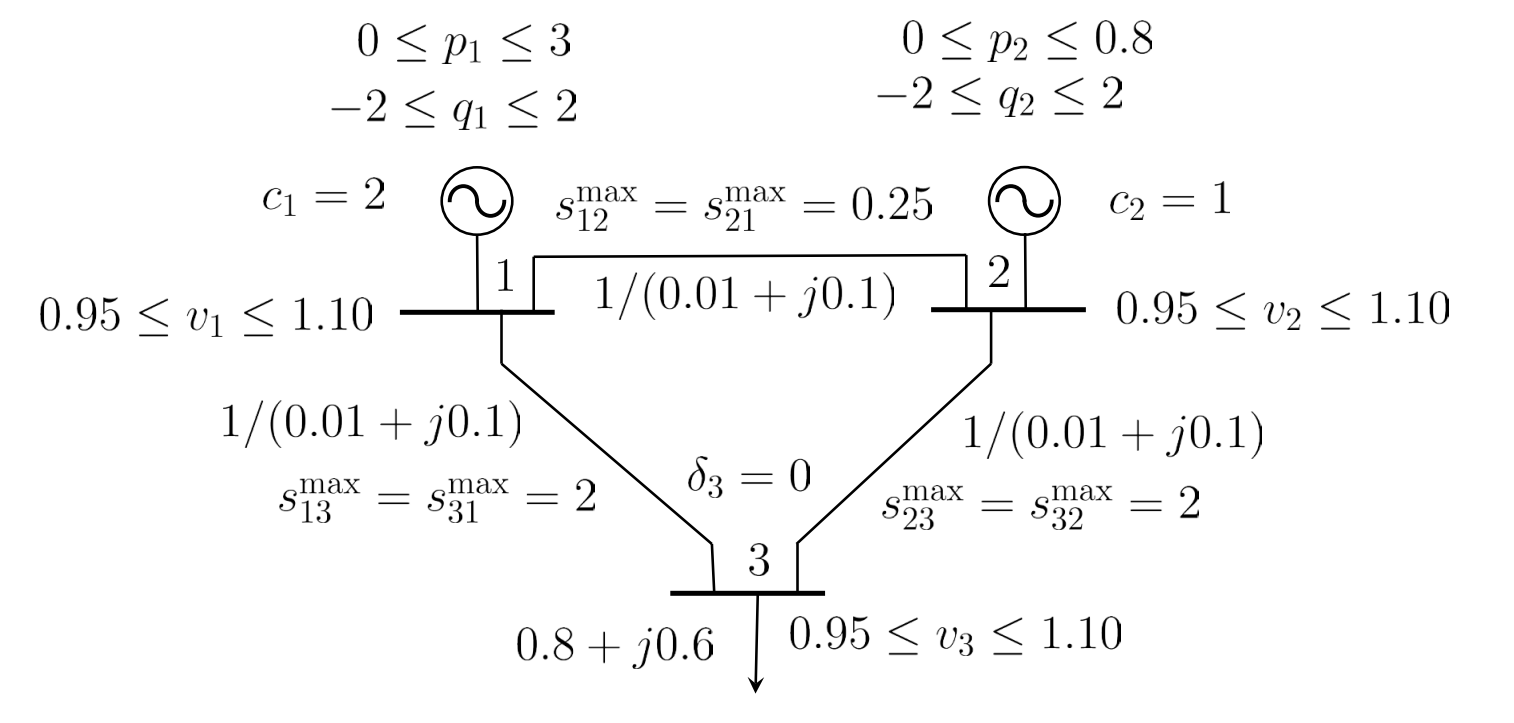

In [34]:
using JuMP
using Ipopt

In [35]:

# Conjunto de barras
N = [1, 2, 3]

# Conjunto de geradores
G = [1, 2]

# Conjunto de linhas (pares ordenados)
L = [(1,2), (2,1),
     (1,3), (3,1),
     (2,3), (3,2)]


6-element Vector{Tuple{Int64, Int64}}:
 (1, 2)
 (2, 1)
 (1, 3)
 (3, 1)
 (2, 3)
 (3, 2)

In [36]:

# Impedância das linhas
r = 0.01
x = 0.1

# Admitância
g = r / (r^2 + x^2)
b = -x / (r^2 + x^2)


-9.900990099009901

In [37]:
#Cargas

Pd = Dict(1 => 0.0, 2 => 0.0, 3 => 0.8)
Qd = Dict(1 => 0.0, 2 => 0.0, 3 => 0.6)


Dict{Int64, Float64} with 3 entries:
  2 => 0.0
  3 => 0.6
  1 => 0.0

In [38]:
#Custo de Geração
cost = Dict(1 => 2.0, 2 => 1.0)


Dict{Int64, Float64} with 2 entries:
  2 => 1.0
  1 => 2.0

In [39]:
#Limites Operacionais

Pmin = Dict(1 => 0.0, 2 => 0.0)
Pmax = Dict(1 => 3.0, 2 => 0.8)

Qmin = Dict(1 => -2.0, 2 => -2.0)
Qmax = Dict(1 =>  2.0, 2 =>  2.0)

Vmin = 0.95
Vmax = 1.10


1.1

In [40]:
#Limites de Potencia aparente nas linhas

Smax = Dict(
    (1,2) => 0.25, (2,1) => 0.25,
    (1,3) => 2.0,  (3,1) => 2.0,
    (2,3) => 2.0,  (3,2) => 2.0
)


Dict{Tuple{Int64, Int64}, Float64} with 6 entries:
  (3, 2) => 2.0
  (1, 2) => 0.25
  (3, 1) => 2.0
  (1, 3) => 2.0
  (2, 1) => 0.25
  (2, 3) => 2.0

In [41]:

model = Model(Ipopt.Optimizer)
set_silent(model)


In [42]:
#Variaveis de Decisao

#Geração
@variable(model, Pmin[i] <= Pg[i in G] <= Pmax[i])
@variable(model, Qmin[i] <= Qg[i in G] <= Qmax[i])

#Tensoes Nodais
@variable(model, Vmin <= V[i in N] <= Vmax)
@variable(model, delta[i in N])

#Barra de Referencia
@constraint(model, delta[3] == 0)

#Fluxos de Poentenia
@variable(model, Pij[(i,j) in L])
@variable(model, Qij[(i,j) in L])

#Funcao Objetiva
@objective(model, Min, sum(cost[i] * Pg[i] for i in G))



2 Pg[1] + Pg[2]

In [43]:
# Equações de fluxo nas linhas - Potência ativa

for (i,j) in L
    @NLconstraint(model,
        Pij[(i,j)] ==
        V[i]^2 * g -
        V[i]*V[j]*( g*cos(delta[i]-delta[j]) +
                    b*sin(delta[i]-delta[j]) )
    )
end


In [44]:
# Equações de fluxo nas linhas - Potência Reativa
for (i,j) in L
    @NLconstraint(model,
        Qij[(i,j)] ==
        -V[i]^2 * b -
        V[i]*V[j]*( g*sin(delta[i]-delta[j]) -
                    b*cos(delta[i]-delta[j]) )
    )
end


In [45]:
# Balanço de potência (Bus Injection) - Potência ativa

for i in N
    @constraint(model,
        (i in G ? Pg[i] : 0.0) - Pd[i]
        ==
        sum(Pij[(i,j)] for j in N if (i,j) in L)
    )
end


In [46]:
#Balanço de potência (Bus Injection) - Potência Reativa

for i in N
    @constraint(model,
        (i in G ? Qg[i] : 0.0) - Qd[i]
        ==
        sum(Qij[(i,j)] for j in N if (i,j) in L)
    )
end
``


``

In [47]:
# Limites de potência aparente

for (i,j) in L
    @NLconstraint(model,
        Pij[(i,j)]^2 + Qij[(i,j)]^2 <= Smax[(i,j)]^2
    )
end


In [48]:
optimize!(model)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



In [49]:
#Resultado

println("Custo ótimo = ", objective_value(model))

for i in G
    println("Gerador ", i,
            ": Pg = ", value(Pg[i]),
            ", Qg = ", value(Qg[i]))
end

for i in N
    println("Barra ", i,
            ": V = ", value(V[i]),
            ", delta = ", value(delta[i])*180/pi, " deg")
end
``

Custo ótimo = 0.8360786945615122
Gerador 1: Pg = 0.03090683455325289, Qg = 0.3209166923859517
Gerador 2: Pg = 0.7742650254550064, Qg = 0.3308019076966431
Barra 1: V = 1.0977001927052188, delta = 1.2165020931020802 deg
Barra 2: V = 1.0999998938294697, delta = 2.401418523626021 deg
Barra 3: V = 1.0663591316422298, delta = 0.0 deg


``

# **7-Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [ ]:
# code

# **8-Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [23]:

using JuMP
using HiGHS


In [24]:

# Dados
E = [
    90 80 10 50;
    60 70 50 65;
    70 40 80 85
]

R = [70, 50, 85, 35]
Hmax = 80

n_designers, n_projects = size(E)

(3, 4)

In [27]:

# Modelo
model = Model(HiGHS.Optimizer)


A JuMP Model
├ solver: HiGHS
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [28]:

# Variáveis: H[i,j] >= 0
@variable(model, H[1:n_designers, 1:n_projects] >= 0)

# Função objetivo
@objective(model, Max, sum(E[i,j] * H[i,j] for i in 1:n_designers, j in 1:n_projects))

# Restrições: capacidade dos designers
for i in 1:n_designers
    @constraint(model, sum(H[i,j] for j in 1:n_projects) <= Hmax)
end

# Restrições: demanda dos projetos
for j in 1:n_projects
    @constraint(model, sum(H[i,j] for i in 1:n_designers) == R[j])
end


In [29]:

# Resolver
optimize!(model)
``


Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 7 rows; 12 cols; 24 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+01, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [4e+01, 8e+01]
Presolving model
7 rows, 12 cols, 24 nonzeros  0s
Dependent equations search running on 4 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
7 rows, 12 cols, 24 nonzeros  0s
Presolve reductions: rows 7(-0); columns 12(-0); nonzeros 24(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.4995459328e+02 Ph1: 7(24); Du: 12(749.955) 0.0s
          7     1.8825000000e+04 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.8825000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time 

``

In [ ]:

println("Status: ", termination_status(model))
println("Valor objetivo: ", objective_value(model))

for i in 1:n_designers
    for j in 1:n_projects
        h = value(H[i,j])
        if h > 1e-4
            println("Designer $i → Projeto $j : $(round(h, digits=2)) horas")
        end
    end
end


# **9-Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [26]:
# Criação do modelo
# Variáveis 
# Função objetivo: minizar o custo total
# Restrição

using JuMP, HiGHS

# modelo
model = Model(HiGHS.Optimizer)

# Variáveis
@variable(model, y[1:4] >= 0)

# Função objetivo: minimizar o custo total
@objective(model, Min,
    1.0*y[1] +     # Apple
    0.5*y[2] +     # Bread
    2.0*y[3] +     # Milk
    0.3*y[4]       # Egg
)

# Restrições nutricionais
@constraint(model,        # Calories
    100*y[1] + 200*y[2] + 150*y[3] + 70*y[4] >= 500
)

@constraint(model,        # Proteinas
    0.5*y[1] + 4*y[2] + 8*y[3] + 6*y[4] >= 50
)

@constraint(model,        # Vitaminas
    2*y[1] + 10*y[3] >= 100
)

# Resolver
optimize!(model)





Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 3 rows; 4 cols; 10 nonzeros
Coefficient ranges:
  Matrix  [5e-01, 2e+02]
  Cost    [3e-01, 2e+00]
  Bound   [0e+00, 0e+00]
  RHS     [5e+01, 5e+02]
Presolving model
3 rows, 4 cols, 10 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-3); columns 0(-4); nonzeros 0(-10) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Objective value     :  2.0000000000e+01
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


In [29]:

# Resultados
println("Status: ", termination_status(model))
println("Apple  (y1): ", value(y[1]))
println("Bread  (y2): ", value(y[2]))
println("Milk   (y3): ", value(y[3]))
println("Egg    (y4): ", value(y[4]))
println("Custo mínimo total: ", objective_value(model))


Status: OPTIMAL
Apple  (y1): 0.0
Bread  (y2): 0.0
Milk   (y3): 10.0
Egg    (y4): 0.0
Custo mínimo total: 20.0


# **10-Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [20]:
# Criação do modelo
model = Model(HiGHS.Optimizer)

# Variáveis binárias
@variable(model, x1, Bin)  # Tent(Barraca)
@variable(model, x2, Bin)  # Stove(Fogareiro)
@variable(model, x3, Bin)  # Food(Comida)

# Função objetivo: maximizar o valor total
@objective(model, Max, 120*x1 + 80*x2 + 60*x3)

# Restrição de peso
@constraint(model, 2*x1 + 1*x2 + 1*x3 <= 3.5)

# Resolver o modelo
optimize!(model)


Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1 row; 3 cols; 3 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+00]
  Cost    [6e+01, 1e+02]
  Bound   [1e+00, 1e+00]
  RHS     [4e+00, 4e+00]
Presolving model
1 rows, 3 cols, 3 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-1); columns 0(-3); nonzeros 0(-3) - Reduced to empty
Presolve: Optimal

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc.

In [19]:

# Resultados
println("Status: ", termination_status(model))
println("Tent  (x1): ", value(x1))
println("Stove (x2): ", value(x2))
println("Food  (x3): ", value(x3))
println("Valor total ótimo: ", objective_value(model))


Status: OPTIMAL
Tent  (x1): 1.0
Stove (x2): 1.0
Food  (x3): 0.0
Valor total ótimo: 200.0
